In [1]:
from astropy.table import Table
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from matplotlib import colors
import numpy as np
import os
import pathlib
import pandas as pd
import polars as pl

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [4]:
#gaiaids = pl.read_parquet('(#path to#)/allgaiadata.parq').to_pandas()
gaiaids = pl.read_parquet('/Users/mschochet/ASASSN CNN Notebooks/datafiles/allgaiadata.parq').to_pandas()

gidssmol = gaiaids[['asas_sn_id', 'gaia_id']]
del gaiaids

In [5]:
allpred = pd.read_csv('/Users/mschochet/ASASSN CNN Notebooks/datafiles/0fullpred.csv', header=None, names=['asas_sn_id', 'period', 'sigma'])

In [6]:
predcitionsandgaia = pd.merge(gidssmol, allpred, on='asas_sn_id', how='inner').drop_duplicates(subset=['asas_sn_id'])

In [7]:
idmatch = Table.read('files/kepler_dr2_1arcsec.fits', format='fits').to_pandas()
idmatch = idmatch.drop_duplicates(subset=['kepid'])
idmatcher = idmatch[['kepid', 'source_id']]
idmatcher = idmatcher.rename(columns={'kepid':'KIC', 'source_id':'gaia_id'})

In [8]:
gaiatotic = pd.merge(idmatcher, predcitionsandgaia, on='gaia_id', how='inner')
del predcitionsandgaia, idmatcher, idmatch

In [10]:
santos1 = Table.read('files/crossmatch/santos1.txt', format="ascii.cds").to_pandas()
santos2 = Table.read('files/crossmatch/santos2.txt', format="ascii.cds").to_pandas()
santostot = pd.concat([santos1, santos2])

In [227]:
santosmatch = pd.merge(santostot, gaiatotic, on='KIC', how='inner')
santosmatch['frac_err'] =  santosmatch['sigma']/santosmatch['period']
santosmatch['diff'] = np.abs((santosmatch['period']-santosmatch['Prot'])) / santosmatch['Prot']


In [260]:
numonesig = len(santosmatch[santosmatch['sigma']<=1])
numtwosig = len(santosmatch[santosmatch['sigma']<=2])
numthreesig = len(santosmatch[santosmatch['sigma']<=3])
numfoursig = len(santosmatch[santosmatch['sigma']<=4])
numfivesig = len(santosmatch[santosmatch['sigma']<=5])
num6sig = len(santosmatch[santosmatch['sigma']<=6])
num7sig = len(santosmatch[santosmatch['sigma']<=7])
num8sig = len(santosmatch[santosmatch['sigma']<=8])
num9sig = len(santosmatch[santosmatch['sigma']<=9])

tot = len(santosmatch) 

onesigpercen = numonesig/tot * 100
twosigpercen = numtwosig/tot * 100
threesigpercen =  numthreesig/tot * 100
foursigpercen =  numfoursig/tot * 100
fivesigpercen =  numfivesig/tot * 100

sixperc = num6sig/tot * 100
sevperc = num7sig/tot * 100
eigperc = num8sig/tot * 100
ninperc = num9sig/tot * 100

sig2 = santosmatch[santosmatch['sigma']<=2]
goodsig2 = sig2[sig2['diff']<=0.1]
percsig2 = (len(goodsig2)/len(sig2)) * 100

sig3 = santosmatch[santosmatch['sigma']<=3]
goodsig3 = sig3[sig3['diff']<=0.1]
percsig3 = (len(goodsig3)/len(sig3)) * 100

sig4 = santosmatch[santosmatch['sigma']<=4]
goodsig4 = sig4[sig4['diff']<=0.1]
percsig4 = (len(goodsig4)/len(sig4)) * 100

sig5 = santosmatch[santosmatch['sigma']<=5]
goodsig5 = sig5[sig5['diff']<=0.1]
percsig5 = (len(goodsig5)/len(sig5)) * 100

sig6 = santosmatch[santosmatch['sigma']<=6]
goodsig6 = sig6[sig6['diff']<=0.1]
percsig6 = (len(goodsig6)/len(sig6)) * 100

sig7 = santosmatch[santosmatch['sigma']<=7]
goodsig7 = sig7[sig7['diff']<=0.1]
percsig7 = (len(goodsig7)/len(sig7)) * 100

sig8 = santosmatch[santosmatch['sigma']<=8]
goodsig8 = sig8[sig8['diff']<=0.1]
percsig8 = (len(goodsig8)/len(sig8)) * 100

sig9 = santosmatch[santosmatch['sigma']<=9]
goodsig9 = sig9[sig9['diff']<=0.1]
percsig9 = (len(goodsig9)/len(sig9)) * 100


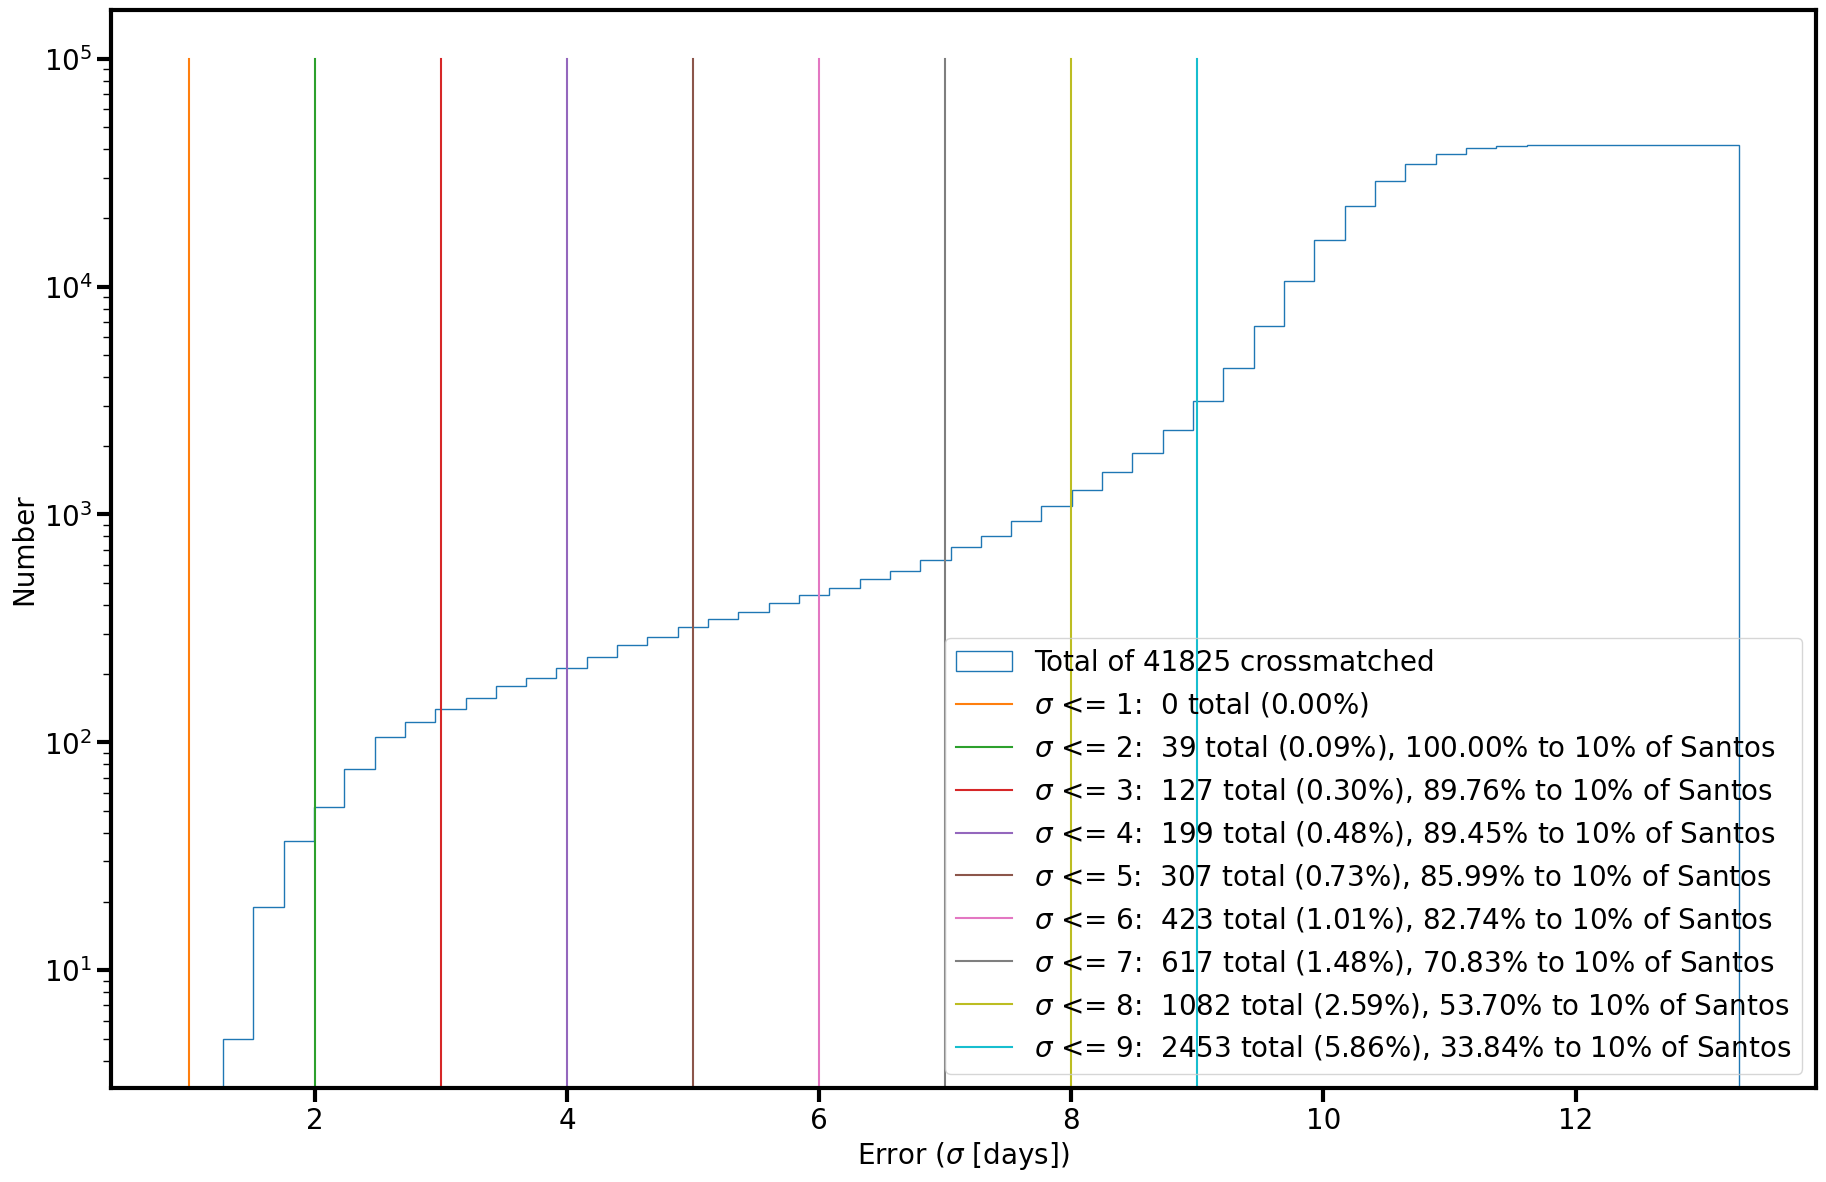

In [262]:
fig, ax = plt.subplots(figsize=(22, 14))

ax.hist(santosmatch['sigma'], bins=50, cumulative=True, histtype='step', label=f'Total of {len(santosmatch)} crossmatched')
ax.plot([1, 1], [0, 100000], label=f'$\sigma$ <= 1:  {numonesig} total ({"%.2f" % onesigpercen}%)')
ax.plot([2, 2], [0, 100000], label=f'$\sigma$ <= 2:  {numtwosig} total ({"%.2f" % twosigpercen}%), {"%.2f" % percsig2}% to 10% of Santos')
ax.plot([3, 3], [0, 100000], label=f'$\sigma$ <= 3:  {numthreesig} total ({"%.2f" % threesigpercen}%), {"%.2f" % percsig3}% to 10% of Santos')
ax.plot([4, 4], [0, 100000], label=f'$\sigma$ <= 4:  {numfoursig} total ({"%.2f" % foursigpercen}%), {"%.2f" % percsig4}% to 10% of Santos')
ax.plot([5, 5], [0, 100000], label=f'$\sigma$ <= 5:  {numfivesig} total ({"%.2f" % fivesigpercen}%), {"%.2f" % percsig5}% to 10% of Santos')
ax.plot([6, 6], [0, 100000], label=f'$\sigma$ <= 6:  {num6sig} total ({"%.2f" % sixperc}%), {"%.2f" % percsig6}% to 10% of Santos')
ax.plot([7, 7], [0, 100000], label=f'$\sigma$ <= 7:  {num7sig} total ({"%.2f" % sevperc}%), {"%.2f" % percsig7}% to 10% of Santos')
ax.plot([8, 8], [0, 100000], label=f'$\sigma$ <= 8:  {num8sig} total ({"%.2f" % eigperc}%), {"%.2f" % percsig8}% to 10% of Santos')
ax.plot([9, 9], [0, 100000], label=f'$\sigma$ <= 9:  {num9sig} total ({"%.2f" % ninperc}%), {"%.2f" % percsig9}% to 10% of Santos')

ax.set_xlabel(r'Error ($\sigma$ [days])')
ax.set_ylabel('Number')
plt.yscale('log')
plt.legend()

In [ ]:
fracerrnum50 = len(santosmatch[santosmatch['frac_err']<=0.5])
fracerrnum25 = len(santosmatch[santosmatch['frac_err']<=0.25])
fracerrnum10 = len(santosmatch[santosmatch['frac_err']<=0.1])

tot = len(santosmatch) 

fracerrnum50perc = fracerrnum50/tot * 100
fracerrnum25perc = fracerrnum25/tot * 100
fracerrnum10perc =  fracerrnum10/tot * 100

frac50 = santosmatch[santosmatch['frac_err']<=0.5]
goodfrac50 = frac50[frac50['diff']<=0.1]
percfrac50 = (len(goodfrac50)/len(frac50)) * 100

frac25 = santosmatch[santosmatch['frac_err']<=0.25]
goodfrac25 = frac25[frac25['diff']<=0.1]
percfrac25 = (len(goodfrac25)/len(frac25)) * 100

frac10 = santosmatch[santosmatch['frac_err']<=0.1]
goodfrac10 = frac10[frac10['diff']<=0.1]
percfrac10 = (len(goodfrac10)/len(frac10)) * 100

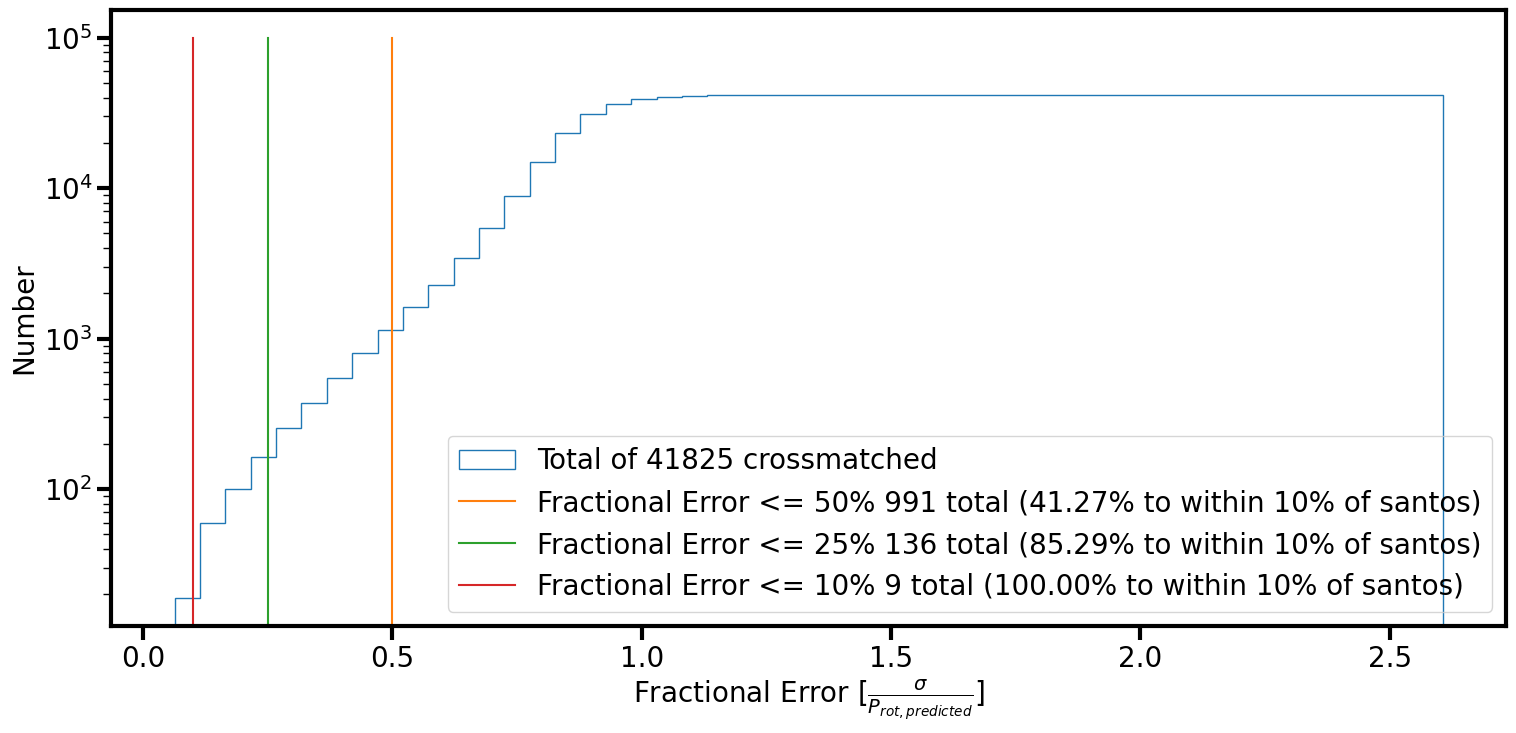

In [256]:
fig, ax = plt.subplots(figsize=(18, 8))
title = r"Fractional Error"

ax.hist(santosmatch['frac_err'], bins=50, cumulative=True, histtype='step', label=f'Total of {len(santosmatch)} crossmatched')
ax.plot([0.5, 0.5], [0, 100000], label=f'{title} <= 50% {fracerrnum50} total ({"%.2f" % percfrac50}% to within 10% of santos)')
ax.plot([0.25, 0.25], [0, 100000], label=f'{title} <= 25% {fracerrnum25} total ({"%.2f" % percfrac25}% to within 10% of santos)')
ax.plot([0.1, 0.1], [0, 100000], label=f'{title} <= 10% {fracerrnum10} total ({"%.2f" % percfrac10}% to within 10% of santos)')

ax.set_xlabel(r'Fractional Error [$\frac{\sigma}{P_{rot, predicted}}$]')
ax.set_ylabel('Number')
plt.yscale('log')
plt.legend()

In [165]:
sim_input_log6 = "files/testing_csvs_section5/simulation_input_30_log6.csv"
cnn_periodsl6 = pd.read_csv(sim_input_log6, header=0, index_col="simulation_number").sort_index().rename(columns={'period':'true_period'})
cnn_periodsl6.index.names = ['sim_id']
cnn_periods_test_log6 = cnn_periodsl6[900000:]
table3_row1 = pd.read_csv("files/testing_csvs_section5/6_clump_nor_norm_nan_all/asassn_clump_0_predictions.csv", header=0).sort_index().join(cnn_periodsl6, how="inner").eval("frac = sigma/period").query("period > 0")
table3_row1['frac_err'] = table3_row1['sigma']/table3_row1['period']
table3_row1['diff'] = np.abs(table3_row1['period']- table3_row1['true_period'])/table3_row1['true_period']

In [275]:
numonesig = len(table3_row1[table3_row1['sigma']<=1])
numtwosig = len(table3_row1[table3_row1['sigma']<=2])
numthreesig = len(table3_row1[table3_row1['sigma']<=3])
numfoursig = len(table3_row1[table3_row1['sigma']<=4])
numfivesig = len(table3_row1[table3_row1['sigma']<=5])
num6sig = len(table3_row1[table3_row1['sigma']<=6])
num7sig = len(table3_row1[table3_row1['sigma']<=7])
num8sig = len(table3_row1[table3_row1['sigma']<=8])
num9sig = len(table3_row1[table3_row1['sigma']<=9])

tot = len(table3_row1) 

onesigpercen = numonesig/tot * 100
twosigpercen = numtwosig/tot * 100
threesigpercen =  numthreesig/tot * 100
foursigpercen =  numfoursig/tot * 100
fivesigpercen =  numfivesig/tot * 100

sixperc = num6sig/tot * 100
sevperc = num7sig/tot * 100
eigperc = num8sig/tot * 100
ninperc = num9sig/tot * 100

sig2 = table3_row1[table3_row1['sigma']<=2]
goodsig2 = sig2[sig2['diff']<=0.1]
percsig2 = (len(goodsig2)/len(sig2)) * 100

sig3 = table3_row1[table3_row1['sigma']<=3]
goodsig3 = sig3[sig3['diff']<=0.1]
percsig3 = (len(goodsig3)/len(sig3)) * 100

sig4 = table3_row1[table3_row1['sigma']<=4]
goodsig4 = sig4[sig4['diff']<=0.1]
percsig4 = (len(goodsig4)/len(sig4)) * 100

sig5 = table3_row1[table3_row1['sigma']<=5]
goodsig5 = sig5[sig5['diff']<=0.1]
percsig5 = (len(goodsig5)/len(sig5)) * 100

sig6 = table3_row1[table3_row1['sigma']<=6]
goodsig6 = sig6[sig6['diff']<=0.1]
percsig6 = (len(goodsig6)/len(sig6)) * 100

sig7 = table3_row1[table3_row1['sigma']<=7]
goodsig7 = sig7[sig7['diff']<=0.1]
percsig7 = (len(goodsig7)/len(sig7)) * 100

sig8 = table3_row1[table3_row1['sigma']<=8]
goodsig8 = sig8[sig8['diff']<=0.1]
percsig8 = (len(goodsig8)/len(sig8)) * 100

sig9 = table3_row1[table3_row1['sigma']<=9]
goodsig9 = sig9[sig9['diff']<=0.1]
percsig9 = (len(goodsig9)/len(sig9)) * 100


/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_61998/628025637.py:18: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 5000000)


(6.2833580490719845, 5000000)

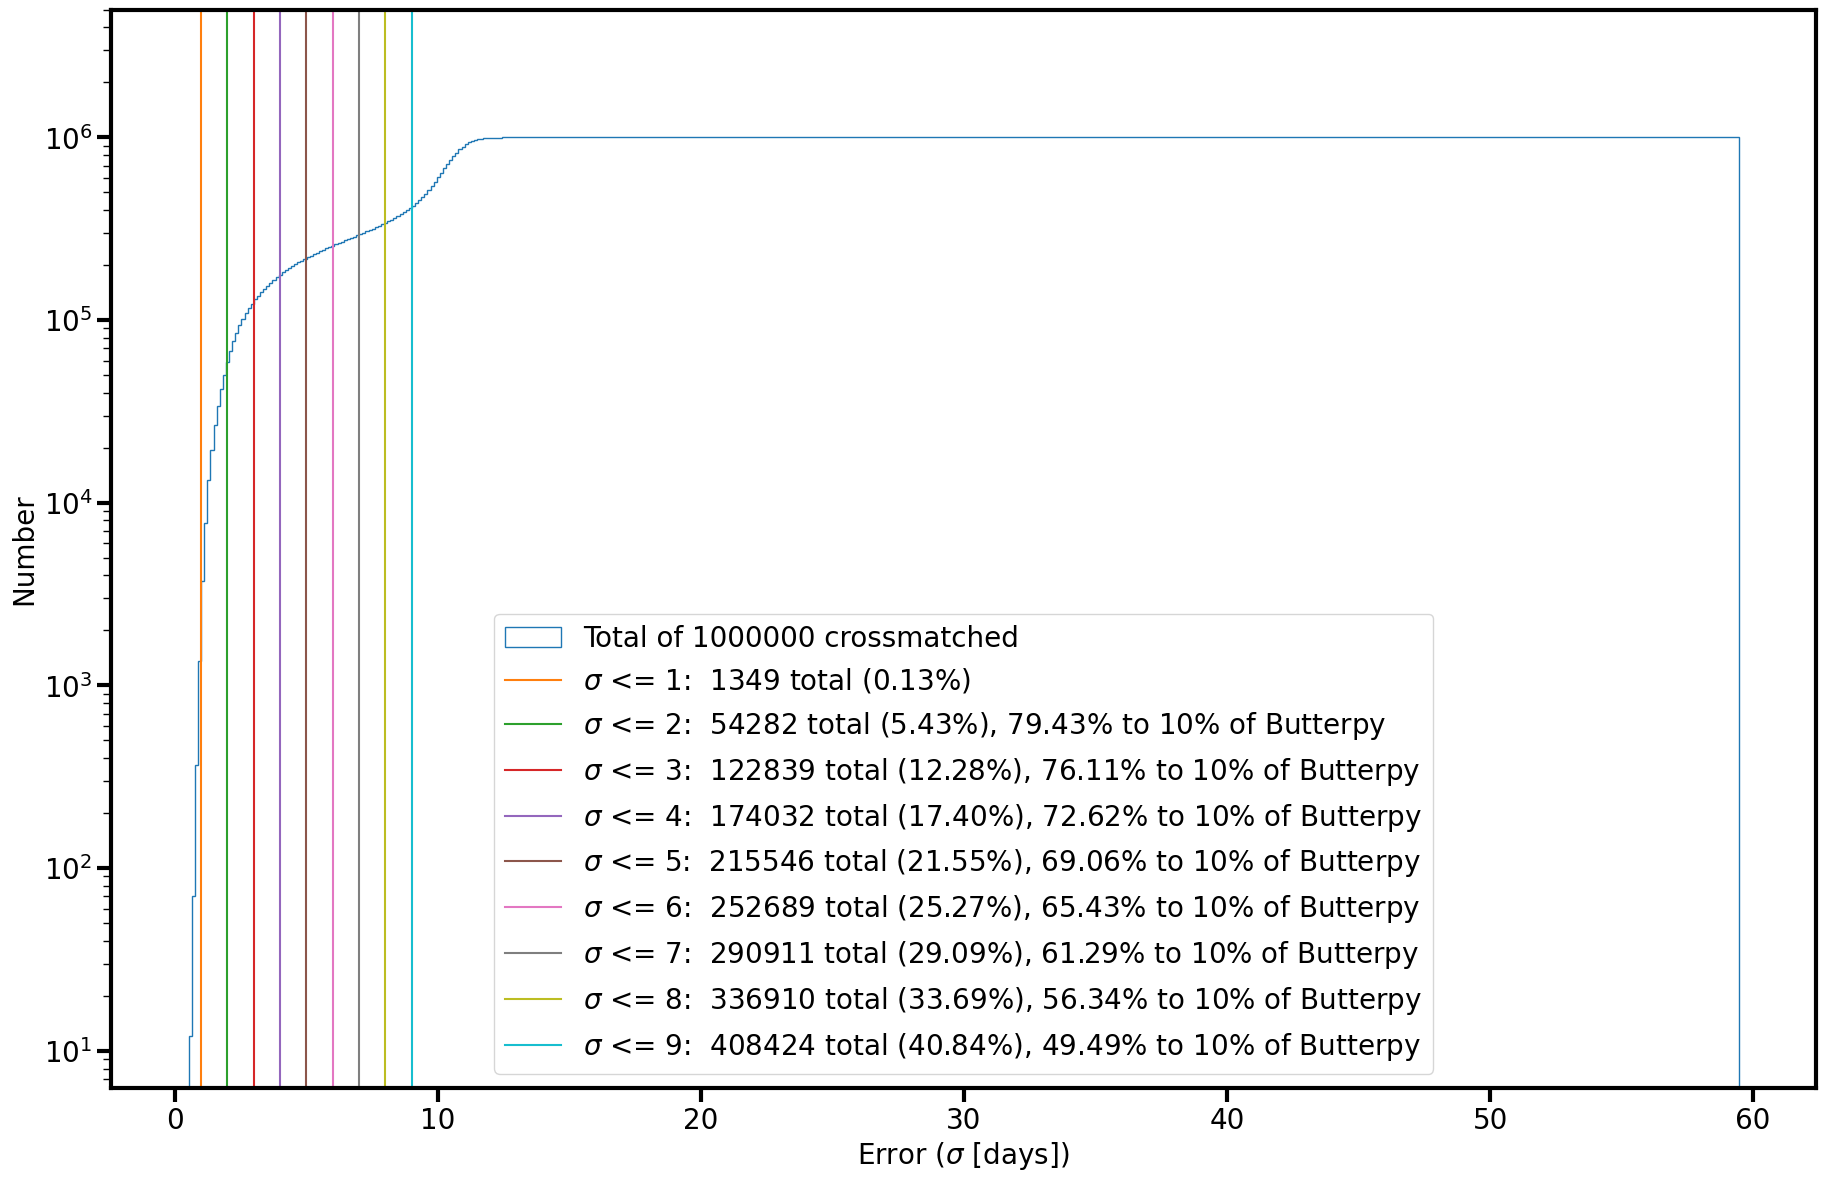

In [276]:
fig, ax = plt.subplots(figsize=(22, 14))

ax.hist(table3_row1['sigma'], bins=500, cumulative=True, histtype='step', label=f'Total of {len(table3_row1)} crossmatched')
ax.plot([1, 1], [0, 5000000], label=f'$\sigma$ <= 1:  {numonesig} total ({"%.2f" % onesigpercen}%)')
ax.plot([2, 2], [0, 5000000], label=f'$\sigma$ <= 2:  {numtwosig} total ({"%.2f" % twosigpercen}%), {"%.2f" % percsig2}% to 10% of Butterpy')
ax.plot([3, 3], [0, 5000000], label=f'$\sigma$ <= 3:  {numthreesig} total ({"%.2f" % threesigpercen}%), {"%.2f" % percsig3}% to 10% of Butterpy')
ax.plot([4, 4], [0, 5000000], label=f'$\sigma$ <= 4:  {numfoursig} total ({"%.2f" % foursigpercen}%), {"%.2f" % percsig4}% to 10% of Butterpy')
ax.plot([5, 5], [0, 5000000], label=f'$\sigma$ <= 5:  {numfivesig} total ({"%.2f" % fivesigpercen}%), {"%.2f" % percsig5}% to 10% of Butterpy')
ax.plot([6, 6], [0, 5000000], label=f'$\sigma$ <= 6:  {num6sig} total ({"%.2f" % sixperc}%), {"%.2f" % percsig6}% to 10% of Butterpy')
ax.plot([7, 7], [0, 5000000], label=f'$\sigma$ <= 7:  {num7sig} total ({"%.2f" % sevperc}%), {"%.2f" % percsig7}% to 10% of Butterpy')
ax.plot([8, 8], [0, 5000000], label=f'$\sigma$ <= 8:  {num8sig} total ({"%.2f" % eigperc}%), {"%.2f" % percsig8}% to 10% of Butterpy')
ax.plot([9, 9], [0, 5000000], label=f'$\sigma$ <= 9:  {num9sig} total ({"%.2f" % ninperc}%), {"%.2f" % percsig9}% to 10% of Butterpy')

ax.set_xlabel(r'Error ($\sigma$ [days])')
ax.set_ylabel('Number')
plt.yscale('log')
plt.legend()
plt.ylim(0, 5000000)

In [277]:
fracerrnum50 = len(table3_row1[table3_row1['frac_err']<=0.5])
fracerrnum25 = len(table3_row1[table3_row1['frac_err']<=0.25])
fracerrnum10 = len(table3_row1[table3_row1['frac_err']<=0.1])

tot = len(table3_row1) 

fracerrnum50perc = fracerrnum50/tot * 100
fracerrnum25perc = fracerrnum25/tot * 100
fracerrnum10perc =  fracerrnum10/tot * 100

frac50 = table3_row1[table3_row1['frac_err']<=0.5]
goodfrac50 = frac50[frac50['diff']<=0.1]
percfrac50 = (len(goodfrac50)/len(frac50)) * 100

frac25 = table3_row1[table3_row1['frac_err']<=0.25]
goodfrac25 = frac25[frac25['diff']<=0.1]
percfrac25 = (len(goodfrac25)/len(frac25)) * 100

frac10 = table3_row1[table3_row1['frac_err']<=0.1]
goodfrac10 = frac10[frac10['diff']<=0.1]
percfrac10 = (len(goodfrac10)/len(frac10)) * 100

/var/folders/s0/h_46lpt56ll2ptpy3684xkym0000gn/T/ipykernel_61998/2339734572.py:13: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(0, 5000000)


(24998.71219875479, 5000000)

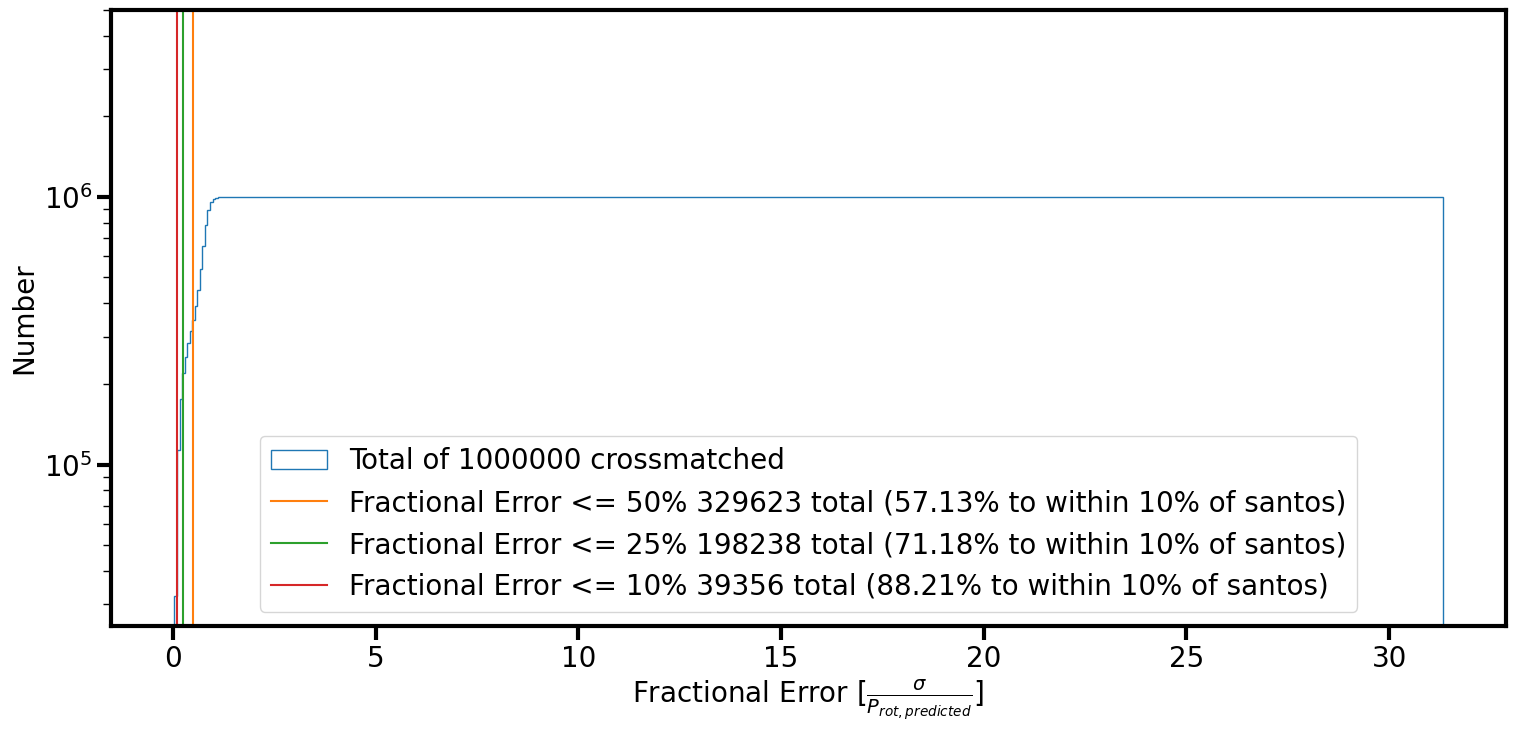

In [278]:
fig, ax = plt.subplots(figsize=(18, 8))
title = r"Fractional Error"

ax.hist(table3_row1['frac_err'], bins=500, cumulative=True, histtype='step', label=f'Total of {len(table3_row1)} crossmatched')
ax.plot([0.5, 0.5], [0, 5000000], label=f'{title} <= 50% {fracerrnum50} total ({"%.2f" % percfrac50}% to within 10% of santos)')
ax.plot([0.25, 0.25], [0, 5000000], label=f'{title} <= 25% {fracerrnum25} total ({"%.2f" % percfrac25}% to within 10% of santos)')
ax.plot([0.1, 0.1], [0, 5000000], label=f'{title} <= 10% {fracerrnum10} total ({"%.2f" % percfrac10}% to within 10% of santos)')

ax.set_xlabel(r'Fractional Error [$\frac{\sigma}{P_{rot, predicted}}$]')
ax.set_ylabel('Number')
plt.yscale('log')
plt.legend()
plt.ylim(0, 5000000)

In [423]:
uncertainties = [1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5]
numdetected = []
fracdetected = []
percenttoten = []

for uncertainty in uncertainties:
    detected = santosmatch[santosmatch['sigma'] <= uncertainty]
    fracdetect = len(detected) / len(santosmatch)
    good = detected[detected['diff']<=0.1]
    try:
        percentrightten = (len(good)/len(detected)) * 100
    except:
        percentrightten = 0
    numdetected.append(len(detected))
    fracdetected.append(fracdetect)
    percenttoten.append(percentrightten)

In [424]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 100

In [425]:
fracdetectedfin = NormalizeData(fracdetected)

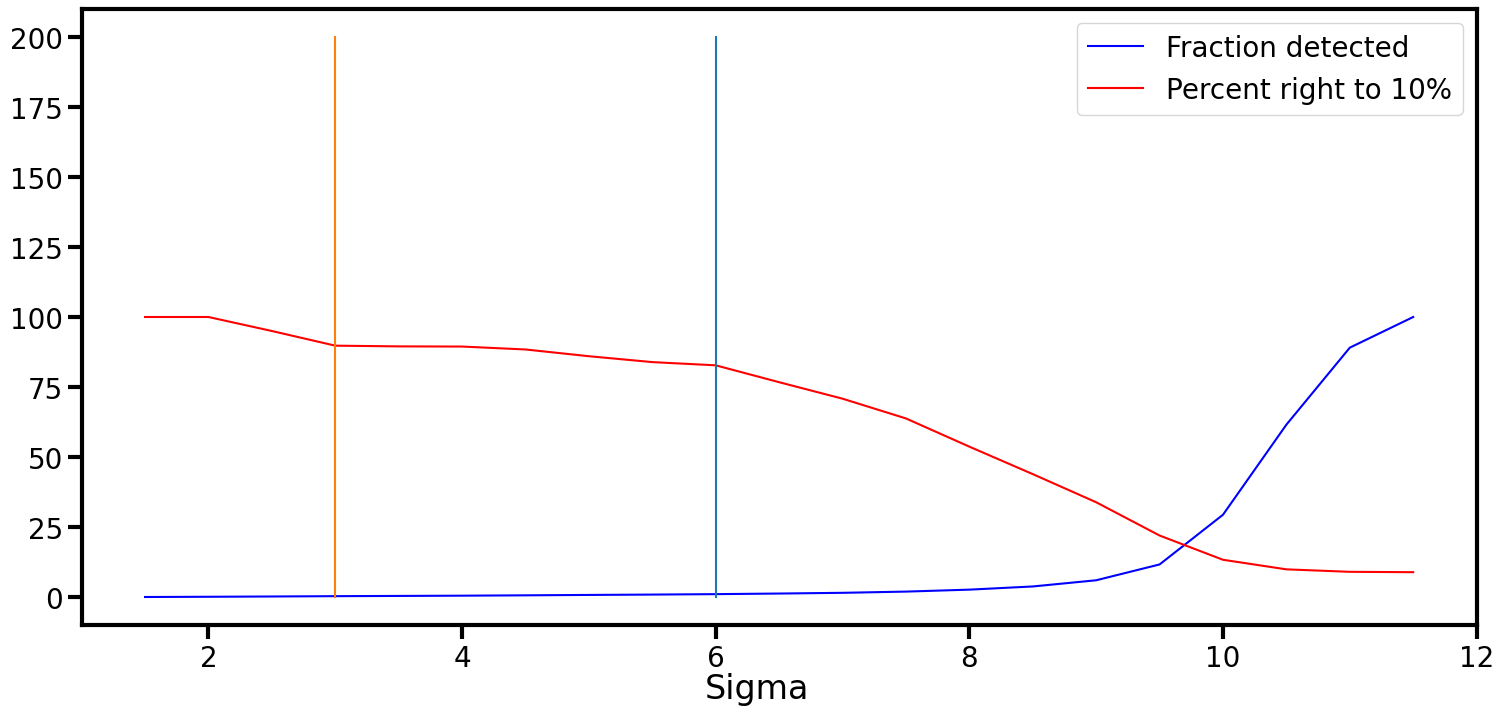

In [426]:
fig, ax = plt.subplots(figsize=(18, 8))

#ax.plot(uncertainties, numdetected, c='k', label='Number detected (/10000)')
ax.plot(uncertainties, fracdetectedfin, c='b', label='Fraction detected')
ax.plot(uncertainties, percenttoten, c='r', label='Percent right to 10%')
fig.supxlabel('Sigma')

ax.plot([6, 6], [0, 200])#, label=f'{title} <= 25% {fracerrnum25} total ({"%.2f" % percfrac25}% to within 10% of santos)')
ax.plot([3, 3], [0, 200])#, label=f'{title} <= 10% {fracerrnum10} total ({"%.2f" % percfrac10}% to within 10% of santos)')

plt.legend()

plt.show()

In [418]:
uncertainties = [0.05, 0.1, 0.15, 0.2, 0.25, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.85, 0.9, 0.95, 1,
                 1.05, 1.1, 1.15, 1.2, 1.25, 1.35, 1.4, 1.45, 1.5]
numdetected = []
fracdetected = []
percenttoten = []

for uncertainty in uncertainties:
    detected = santosmatch[santosmatch['frac_err'] <= uncertainty]
    fracdetect = len(detected) / len(santosmatch)
    good = detected[detected['diff']<=0.1]
    try:
        percentrightten = (len(good)/len(detected)) * 100
    except:
        percentrightten = 0
    numdetected.append(len(detected))
    fracdetected.append(fracdetect)
    percenttoten.append(percentrightten)

In [419]:
def NormalizeData(data):
    return (data - np.min(data)) / (np.max(data) - np.min(data)) * 100

fracdetectedfin = NormalizeData(fracdetected)

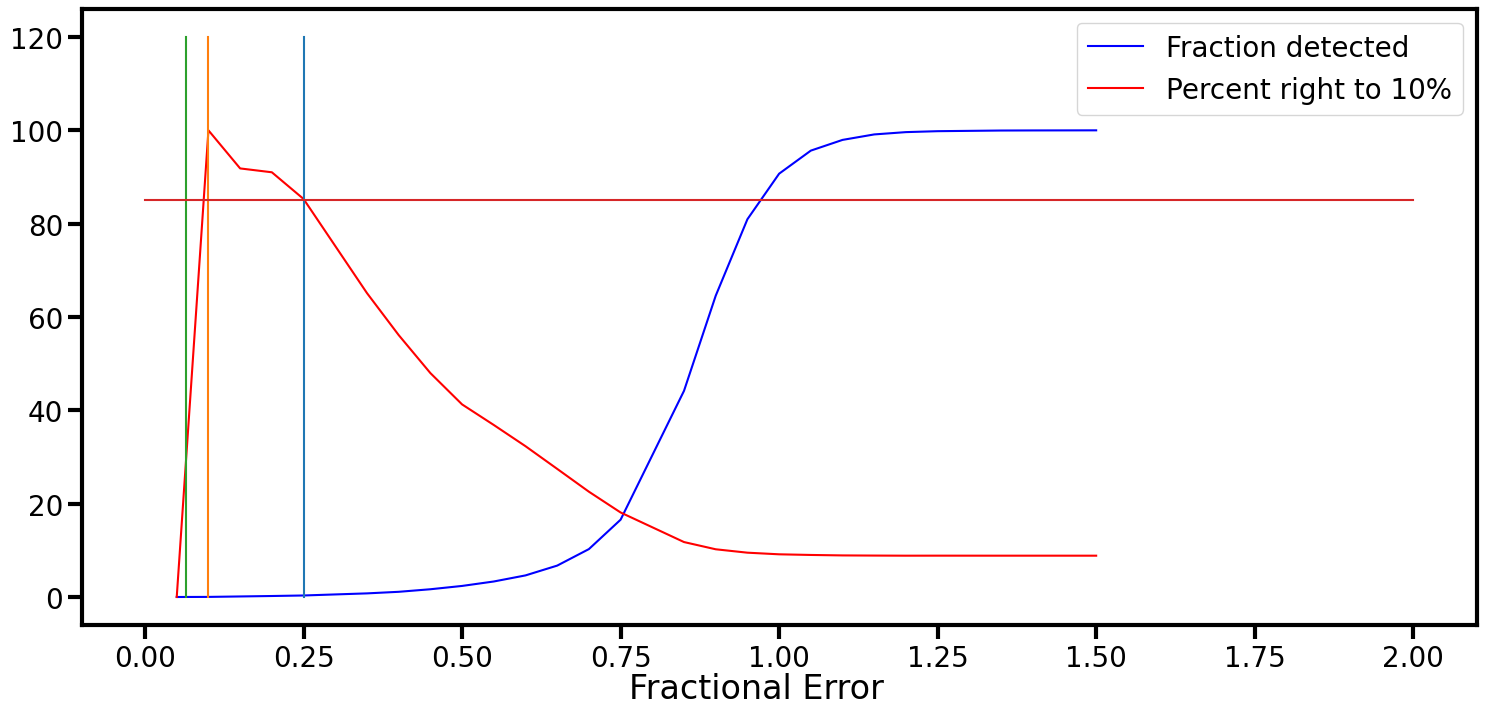

In [ ]:
fig, ax = plt.subplots(figsize=(18, 8))

#ax.plot(uncertainties, numdetected, c='k', label='Number detected (/10000)')
ax.plot(uncertainties, fracdetectedfin, c='b', label='Fraction detected')
ax.plot(uncertainties, percenttoten, c='r', label='Percent right to 10%')
fig.supxlabel('Fractional Error')
ax.plot([0.25, 0.25], [0, 120])#, label=f'{title} <= 25% {fracerrnum25} total ({"%.2f" % percfrac25}% to within 10% of santos)')
ax.plot([0.1, 0.1], [0, 120])#, label=f'{title} <= 10% {fracerrnum10} total ({"%.2f" % percfrac10}% to within 10% of santos)')
ax.plot([0.065, 0.065], [0, 120])#, label=f'{title} <= 10% {fracerrnum10} total ({"%.2f" % percfrac10}% to within 10% of santos)')
#ax.plot([0, 2], [85, 85])
#rrivera27@csamauto.com
plt.legend()

plt.show()

In [439]:
allpred['frac'] = allpred['sigma']/allpred['period']
fracerr25 = allpred[allpred['frac']<0.25]
len(fracerr25[fracerr25['period']<10])

5060

In [440]:
allpred['frac'] = allpred['sigma']/allpred['period']
sig5 = allpred[allpred['sigma']<5]
len(sig5[sig5['period']<10])

46124